# trailstats: a tour

`trailstats` analyses GPS activity recordings (GPX files) offline. This notebook uses
the package as a library; everything shown here is also available from the command line
via `python -m trailstats`.

In [1]:
from pathlib import Path

import pandas as pd

from trailstats import (
    build_log,
    load_gpx,
    personal_bests,
    splits,
    summarize,
    weekly_totals,
)
from trailstats.analysis import (
    best_effort,
    elevation_gain,
    smooth_elevation,
    to_dataframe,
)
from trailstats.plotting import plot_comparison, plot_overview, plot_weekly

DATA = Path("..") / "data"

## Loading a track

`load_gpx` turns a GPX file into a `Track`: a name and a list of `TrackPoint`s.

In [2]:
track = load_gpx(DATA / "hike_corvara_passo_gardena.gpx")
track.name, len(track), track.duration

('Corvara - Passo Gardena', 6692, datetime.timedelta(seconds=6691))

In [3]:
frame = to_dataframe(track)
frame[["lat", "lon", "ele", "dist_km", "dt_s", "speed_ms"]].head()

,lat,lon,ele,dist_km,dt_s,speed_ms
0,46.547692,11.873913,1549.800049,0.000000,0.0,0.000000
1,46.547691,11.873900,1549.800049,0.000977,1.0,0.977171
2,46.547696,11.873885,1549.800049,0.002293,1.0,1.315984
3,46.547704,11.873865,1549.800049,0.004015,1.0,1.722175
4,46.547712,11.873846,1549.800049,0.005702,1.0,1.686371


## Why raw GPS elevation cannot be trusted

Consumer GPS altitude jitters by a few metres every second. Summing every small rise
gives an ascent figure that is far too large. `trailstats` smooths the elevation with a
rolling median and only counts climbs above a threshold.

The size of the error depends on the recorder: a phone is much worse than a watch with
a barometric altimeter.

In [4]:
activities = [
    "walk_osmand_1k",
    "walk_osmand_6k",
    "run_contern_5k",
    "ride_blue_springs_17k",
    "hike_corvara_passo_gardena",
]

rows = []
for name in activities:
    points = to_dataframe(load_gpx(DATA / f"{name}.gpx"))
    raw, _ = elevation_gain(points["ele"], threshold_m=0.0)
    smoothed, _ = elevation_gain(smooth_elevation(points))
    rows.append(
        {
            "activity": name,
            "raw ascent (m)": round(raw),
            "smoothed ascent (m)": round(smoothed),
            "inflation": round(raw / smoothed, 1) if smoothed else None,
        }
    )

pd.DataFrame(rows).sort_values("inflation", ascending=False)

,activity,raw ascent (m),smoothed ascent (m),inflation
0,walk_osmand_1k,123,17,7.3
1,walk_osmand_6k,833,293,2.8
2,run_contern_5k,73,36,2.0
3,ride_blue_springs_17k,233,139,1.7
4,hike_corvara_passo_gardena,637,599,1.1


## Summary metrics

`summarize` returns an `ActivityStats` with distance, moving time, pace and ascent.

In [5]:
stats = summarize(track)
print(f"distance    {stats.distance_km:.2f} km")
print(f"duration    {stats.duration}")
print(f"moving time {stats.moving_time}")
print(f"moving pace {stats.moving_pace}")
print(
    f"ascent      {stats.elevation_gain_m:.0f} m (raw GPS said {stats.raw_elevation_gain_m:.0f} m)"
)

distance    6.81 km
duration    1:51:31
moving time 1:31:26
moving pace 0:13:25.416145
ascent      599 m (raw GPS said 637 m)


## Splits and best efforts

Splits divide an activity into fixed-distance sections. `best_effort` searches for the
fastest continuous section of a given distance using a sliding window, which costs one
pass over the track.

In [6]:
run = load_gpx(DATA / "run_imola_24k.gpx")
pd.DataFrame(
    [
        {
            "km": s.index,
            "distance": round(s.distance_km, 2),
            "time": s.duration,
            "pace": s.pace,
            "ascent": round(s.elevation_gain_m),
        }
        for s in splits(run)
    ]
)

,km,distance,time,pace,ascent
0,1,1.00,0 days 00:05:34,0 days 00:05:35.045367,0
1,2,1.00,0 days 00:05:33,0 days 00:05:32.163439,3
2,3,1.00,0 days 00:05:32,0 days 00:05:32.339907,0
3,4,1.00,0 days 00:05:23,0 days 00:05:23.315551,0
4,5,1.00,0 days 00:05:25,0 days 00:05:24.633800,0
5,6,1.00,0 days 00:05:37,0 days 00:05:37.022496,0
6,7,1.00,0 days 00:05:53,0 days 00:05:53.150296,21
7,8,1.00,0 days 00:05:23,0 days 00:05:23.572573,6
8,9,1.00,0 days 00:07:04,0 days 00:07:02.738484,0
9,10,1.00,0 days 00:05:28,0 days 00:05:28.774942,0


In [7]:
for distance in (1, 5, 10, 21.1):
    effort = best_effort(run, distance)
    if effort is None:
        print(f"{distance:>5} km  not reached")
    else:
        print(
            f"{distance:>5} km  {effort.duration}  starting at {effort.start_km:.2f} km"
        )

    1 km  0:05:21  starting at 3.30 km
    5 km  0:27:24  starting at 0.83 km
   10 km  0:56:53  starting at 0.00 km
 21.1 km  2:09:29  starting at 0.00 km


## Plots

Every plotting function accepts an optional `axes`, so figures can be combined.

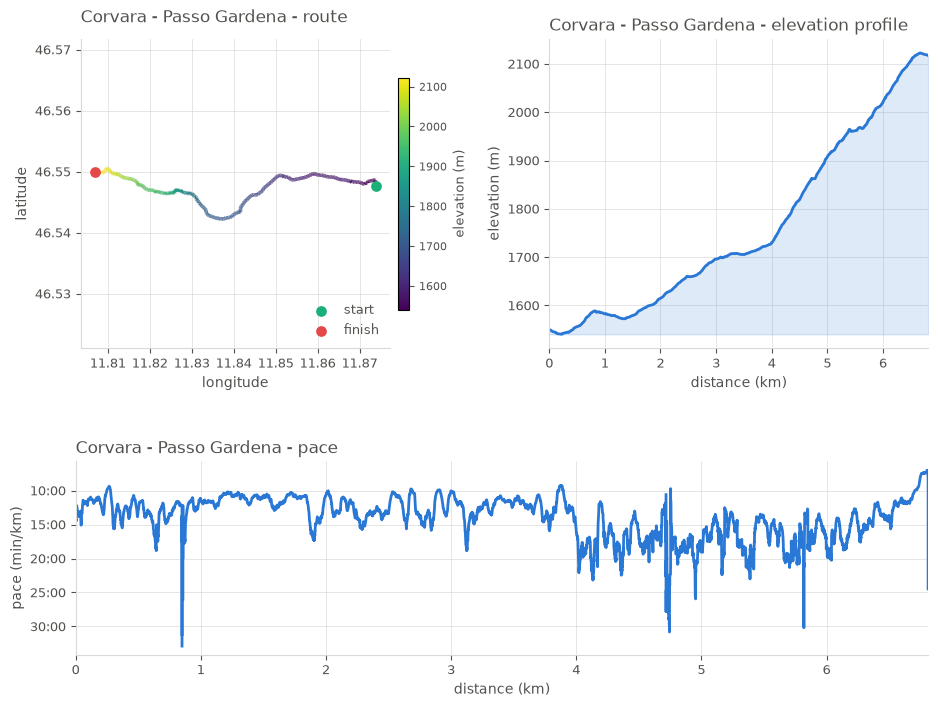

In [8]:
plot_overview(track);

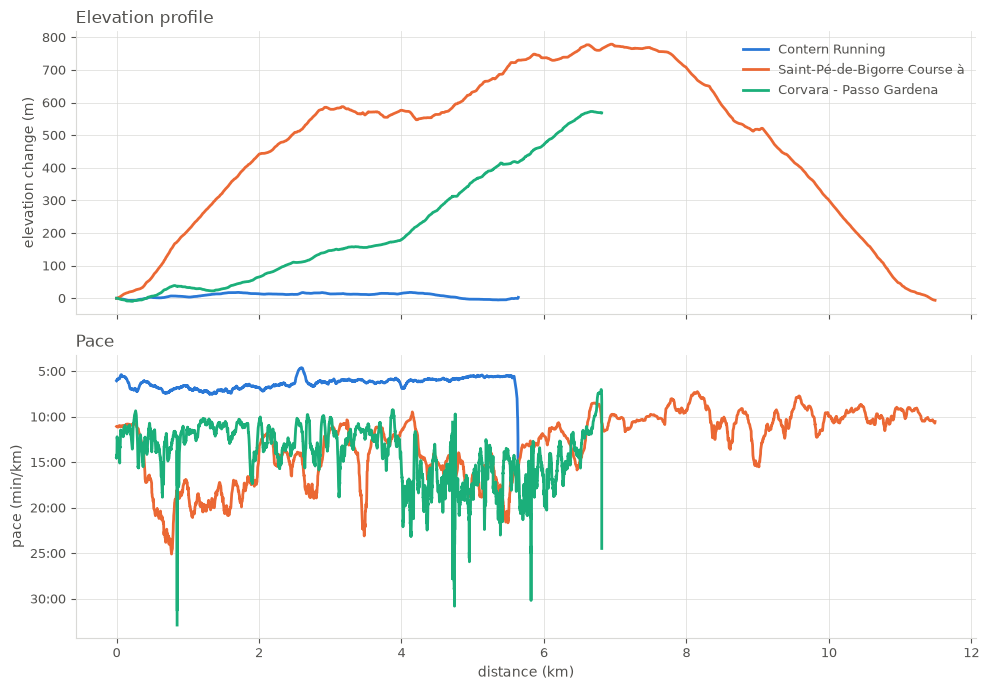

In [9]:
plot_comparison(
    [
        load_gpx(DATA / "run_contern_5k.gpx"),
        load_gpx(DATA / "run_saint_pe_trail_11k.gpx"),
        load_gpx(DATA / "hike_corvara_passo_gardena.gpx"),
    ]
);

## A training log from a folder

`build_log` summarises every activity in a folder into one DataFrame, which can then be
aggregated by week or searched for personal bests.

In [10]:
log = build_log(DATA)
log[["file", "start", "distance_km", "moving_time_s", "elevation_gain_m"]]

,file,start,distance_km,moving_time_s,elevation_gain_m
0,run_contern_5k.gpx,2026-06-08 10:00:37+00:00,5.639888,2136.0,36.000000
1,ride_blue_springs_17k.gpx,2026-08-23 19:25:51+00:00,17.225735,3724.0,138.600006
2,run_owenfs_5k.gpx,2026-08-23 23:45:46+00:00,4.725551,1492.0,9.000000
3,run_imola_24k.gpx,2026-09-12 07:28:00+00:00,24.156941,9193.0,69.000011
4,walk_osmand_6k.gpx,2026-09-16 11:38:26+00:00,5.837850,2137.0,292.800000
5,walk_osmand_1k.gpx,2026-09-18 05:26:15+00:00,1.044313,722.0,16.900000
6,run_saint_pe_trail_11k.gpx,2026-09-18 09:53:24+00:00,11.490452,8819.0,885.600098
7,hike_corvara_passo_gardena.gpx,2026-09-18 10:11:17+00:00,6.811386,5486.0,598.800049


In [11]:
weekly = weekly_totals(log)
weekly

,week,activities,distance_km,hours,elevation_gain_m
0,2026-06-08,1,5.639888,0.593333,36.000000
1,2026-08-17,2,21.951286,1.448889,147.600006
2,2026-09-07,1,24.156941,2.553611,69.000011
3,2026-09-14,4,25.184001,4.767778,1794.100146


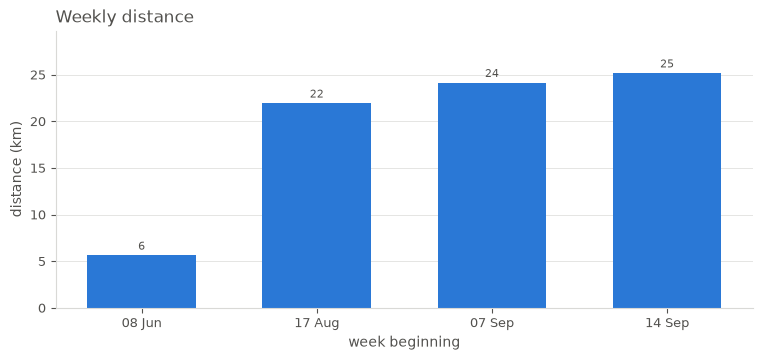

In [12]:
plot_weekly(weekly);

Personal bests are compared across every file that matches a pattern. Narrowing the
pattern keeps a bike ride from taking every record away from the runs.

In [13]:
personal_bests(DATA, pattern="run_*.gpx")

,distance_km,duration_s,file,name
0,1.0,273.0,run_owenfs_5k.gpx,run_owenfs_5k
1,5.0,1644.0,run_imola_24k.gpx,Imola Corsa
2,10.0,3413.0,run_imola_24k.gpx,Imola Corsa
